In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy #manejo de stopwords

pd.set_option('display.max_columns', None)

In [35]:
carpeta_figuras = 'figures'

#Carpeta con los gráficos de este notebook
if not os.path.exists(carpeta_figuras):
    os.makedirs(carpeta_figuras)

In [36]:
df = pd.read_csv('spotify_songs.csv')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18454 entries, 0 to 18453
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  18454 non-null  str    
 1   track_name                18454 non-null  str    
 2   track_artist              18454 non-null  str    
 3   lyrics                    18194 non-null  str    
 4   track_popularity          18454 non-null  int64  
 5   track_album_id            18454 non-null  str    
 6   track_album_name          18454 non-null  str    
 7   track_album_release_date  18454 non-null  str    
 8   playlist_name             18454 non-null  str    
 9   playlist_id               18454 non-null  str    
 10  playlist_genre            18454 non-null  str    
 11  playlist_subgenre         18454 non-null  str    
 12  danceability              18454 non-null  float64
 13  energy                    18454 non-null  float64
 14  key              

In [38]:
df.head()

,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,language
0,0017A6SJgTbfQVU2EtsPNo,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,41,1srJQ0njEQgd8w4XSqI4JQ,Trip,2001-01-01,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,rock,classic rock,0.682,0.401,2,-10.068,1,0.0236,0.27900,0.01170,0.0887,0.566,97.091,235440,tl
1,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,Hard Rock Workout,3YouF0u7waJnolytf9JCXf,rock,hard rock,0.303,0.880,9,-4.739,1,0.0442,0.01170,0.00994,0.3470,0.404,135.225,373512,en
2,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,r&b,new jack swing,0.845,0.652,6,-7.504,0,0.2160,0.00432,0.00723,0.4890,0.650,111.904,262467,en
3,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,Christmas Soul,6FZYc2BvF7tColxO8PBShV,r&b,neo soul,0.425,0.378,5,-5.819,0,0.0341,0.68900,0.00000,0.0664,0.405,118.593,243067,en
4,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,K-Party Dance Mix,37i9dQZF1DX4RDXswvP6Mj,pop,dance pop,0.760,0.887,9,-1.993,1,0.0409,0.03700,0.00000,0.1380,0.240,130.018,193160,en


##### Para comenzar nos concentraremos en las letras de las canciones, por lo que en un principio consideraremos las columnas correspondientes a: nombre del artista, nombre de la canción, género musical y letra

In [39]:
df = df[['track_name', 'track_artist', 'lyrics', 'playlist_genre', 'language']]

In [40]:
df.head()

,track_name,track_artist,lyrics,playlist_genre,language
0,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,rock,tl
1,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",rock,en
2,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",r&b,en
3,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,r&b,en
4,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,pop,en


In [41]:
df.isnull().sum()

track_name          0
track_artist        0
lyrics            260
playlist_genre      0
language          260
dtype: int64

##### Como nos interesa aplicar svd sobre la letra de las canciones, eliminaremos las entradas que no tienen letra.

In [42]:
df = df.dropna(subset=['lyrics'])

In [43]:
df.isnull().sum()

track_name        0
track_artist      0
lyrics            0
playlist_genre    0
language          0
dtype: int64

In [44]:
df['playlist_genre'].unique()

<StringArray>
['rock', 'r&b', 'pop', 'edm', 'latin', 'rap']
Length: 6, dtype: str

##### Para este proyecto, nos gustaría hacer un análisis semántico, particularmente de la letra de las canciones cuyo género musical es el rap y están en español. Por lo que reduciremos el dataset a este género.

In [45]:
df = df[(df['playlist_genre'] == 'rap') & (df['language'] == 'es')].sample(50, random_state=42) #tomamos la muestra de 50 canciones
df = df.reset_index(drop=True)

In [46]:
df.head()

,track_name,track_artist,lyrics,playlist_genre,language
0,A fuego,DrefQuila,"NA Vámono', a fuego, donde no (donde no) Hay t...",rap,es
1,Condiciones,Maikel Delacalle,"Letra de ""Condiciones"" Yo, Maikel DelaCalle A&...",rap,es
2,Otra Botella,Neo Pistea,NA Tony The Kid ¡Tony! ¡Khea Young Flex! (Les ...,rap,es
3,Perros,Cartel De Santa,"CORO ¿Dónde están, perros? (Quiero verlos salt...",rap,es
4,Lalu,Omy de Oro,NA Lanalizer got the fire Quieren que le baje ...,rap,es


In [47]:
df['cl_lyrics'] = df['lyrics'].str.strip('NA')

## P2. Hipótesis Inicial:
##### Como grupo pensamos que en general, un tema del que se escribe mucho en la música popular independiente de su género es el amor y el desamor, por lo que esperamos que palabras relacionadas a esos temas aparezcan como relevantes. Además, en latinoamérica es común en las letras de canciones urbanas, la temática de 'alardeo', es decir, incorporar frases relacionadas con el éxito, el dinero, llegar a la cima, ganar, perder, entre otras. Como tambien expresiones u 'onomatopeyas' cómo: yeah, dale, dímelo y similares. Por lo que tambien esperamos que estas palabras aparezcan. 

## P3. Preprocesamiento del texto
### Explicación: 
##### Para el preprocesamiento de los datos, utilizamos como guía el código del notebook de ejemplo que se mostró en clases con los archivos del curso ('lsa_corpus_curso.html').

##### La lógica del procedimiento a seguir es la siguiente:
- Se utilizó el modelo 'es_core_news_sm' de la librería spacy que permite separar el texto en tokens (o pequeños fragmentos). Durante el proceso de limpieza se hizo una normalización a minúsculas (es decir, aplicar str.lower a cada fragmento) y también se filtraron todos los caracteres que no son letras (considere números, caracteres especiales, emojis, y similares). 

- Luego siguiendo el ejemplo visto en clases, se aplicó lematización para simplificar y unificar palabras similares bajo un mismo significado (por ejemplo, gané, ganando se combinan bajo una sola palabra 'ganar' y así para todas las palabras).

- También se eliminaron las stopwords, palabras como conectores, conjunciones y similares que no aportan mucho al análisis, así como los signos de puntuación. Para esto se utilizó la lista de stopwords que proporciona la librería spacy.

- Finalmente, se sigue la recomendación presentada en el enunciado de construir la matriz TF-IDF sobre el conjunto de datos ya limpio.

##### Justificación: El procesamiento elegido es razonable porque las letras de canciones, en especial aquellas que corresponden a improvisaciones o raps tienden a tener un alto número de conectores o palabras que podemos considerar como stopwords. Asimismo, dentro de la complejidad de los juegos de palabras en las letras de raps o improvisaciones, a menudo se prioriza la rima y la creatividad por encima de la coherencia, por lo que lematizar nos ayuda a 'estandarizar' o simplificar el amplio rango de vocabulario que se usa en este género musical. Con esto, procuramos eliminar el mayor ruido posible de los datos, ayudandonos para el análisis posterior.

In [48]:
!python -m spacy download es_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ----------------------------- ---------- 9.4/12.9 MB 47.2 MB/s eta 0:00:01
     --------------------------------------- 12.9/12.9 MB 42.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])

# Función generada con Gemini con el propósito  de limpiar el texto de las letras de las canciones,
# esto incluye eliminar stopwords, signos de puntuación y tomar los lemas de las palabras.
def limpiar_texto(columna):
    textos_limpios = []
    
    # nlp.pipe es la forma más rápida de procesar muchas filas
    for doc in nlp.pipe(columna.astype(str), batch_size=50):
        # Filtramos: 
        # - token.lemma_ : toma la base de la palabra
        # - not token.is_stop : elimina stopwords
        # - not token.is_punct : elimina signos de puntuación
        # - token.is_alpha : asegura que sean letras (elimina números o símbolos raros)
        tokens = [token.lemma_.lower() for token in doc 
                  if not token.is_stop and not token.is_punct and token.is_alpha]
        
        # Volvemos a unir los lemas en una sola cadena de texto
        textos_limpios.append(" ".join(tokens))
        
    return textos_limpios

#Aplicamos esta función a la columna con las letras de las canciones
#seleccionadas y obtenemos una nueva columna con el texto limpio y preparado para el análisis.
df['cl_lyrics'] = limpiar_texto(df['lyrics']) 

In [50]:
# Un ejemplo del resultado de la limpieza
print(df[['lyrics', 'cl_lyrics']].head(1))

                                              lyrics  \
0  NA Vámono', a fuego, donde no (donde no) Hay t...   

                                           cl_lyrics  
0  na vámono fuego tiempo reloj reloj envidiosos ...  


##### Ahora se construye la matriz TF-IDF sobre la columna cl_lyrics

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [52]:
# Obtenemos las stopwords de spacy como un set y las convertimos a una lista 
# para usarlas en el vectorizador
stopwords = list(nlp.Defaults.stop_words)

## P4. TF-ID y construcción de la matriz textual

##### Se eligió usar TF-ID en vez de conteos crudos por recomendación de enunciado. Tfid Vectorizer nos entrega la matriz documento-término, así que se toma la transpuesta para trabajar con la matriz término-documento, a esta llamamos matriz 'A_final' que necesitamos para aplicar SVD. Para la vectorización, primero se descartan los términos de menos de 3 letrasa, se consideran unigramas y bigramas, y se descartan los términos que aparecieran en más del 80% de los documentos o que en menos de 2 documentos.

In [53]:
# Código rescatado del notebook de ejmplo con los apuntes del curso
vectorizer_final = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    stop_words=stopwords,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
)
# Matriz documento-término
X_final = vectorizer_final.fit_transform(df['cl_lyrics'])
vocabulario_final = vectorizer_final.get_feature_names_out()
# Matriz término-documento
A_final = X_final.toarray().T

vectorizer_final_counts = CountVectorizer(vocabulary=vocabulario_final)
X_final_counts = vectorizer_final_counts.transform(df['cl_lyrics'])
frecuencias_final = np.asarray(X_final_counts.sum(axis=0)).ravel()

print("Forma de X_final (documentos x terminos):", X_final.shape)
print("Forma de A_final (terminos x documentos):", A_final.shape)
print("Primeros terminos del vocabulario final:", vocabulario_final[:30])
print("Unigramas:", sum(len(t.split()) == 1 for t in vocabulario_final))
print("Bigramas:", sum(len(t.split()) == 2 for t in vocabulario_final))


Forma de X_final (documentos x terminos): (50, 865)
Forma de A_final (terminos x documentos): (865, 50)
Primeros terminos del vocabulario final: ['abajo' 'abandonar' 'abismo' 'abogado' 'abrigo' 'abrir' 'acabar' 'acción'
 'acompañar' 'acordar' 'actitud' 'acá' 'afuerar' 'afuero' 'agarro' 'agua'
 'aguantar' 'ajá' 'alcanzar' 'alex' 'alex killer' 'alguien' 'allá' 'alma'
 'alto' 'amanecer' 'amar' 'amiga' 'amigo' 'amor']
Unigramas: 780
Bigramas: 85


##### Cada entrada de esta matriz A, representa con qué tanto peso aparece el término i en el documento j. En este caso los términos o filas están representadas por las palabras de cada canción presentes en la variable 'vocabulario_final' y las columnas representan el documento, es decir, cada una de las canciones. Las dimensiones de la matriz a, como se puede observar arriba, son 7142 filas y 343 columnas respectivamente.

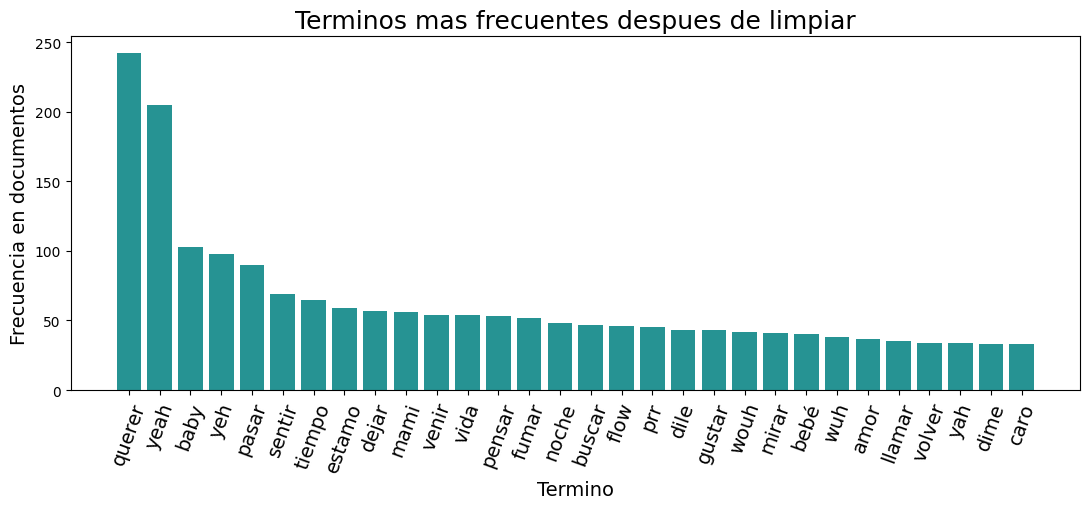

Top 30 terminos mas frecuentes despues de limpiar:


array(['querer', 'yeah', 'baby', 'yeh', 'pasar', 'sentir', 'tiempo',
       'estamo', 'dejar', 'mami', 'venir', 'vida', 'pensar', 'fumar',
       'noche', 'buscar', 'flow', 'prr', 'dile', 'gustar', 'wouh',
       'mirar', 'bebé', 'wuh', 'amor', 'llamar', 'volver', 'yah', 'dime',
       'caro'], dtype=object)

In [54]:
indices_frecuentes_final = np.argsort(frecuencias_final)[::-1][:30]
terminos_frecuentes_final = vocabulario_final[indices_frecuentes_final]
conteos_frecuentes_final = frecuencias_final[indices_frecuentes_final]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.bar(terminos_frecuentes_final, conteos_frecuentes_final, color="teal", alpha=0.85)
ax.set_title("Terminos mas frecuentes despues de limpiar", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia en documentos", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(carpeta_figuras, 'terminos_frecuentes_post_limpieza.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Top 30 terminos mas frecuentes despues de limpiar:")
terminos_frecuentes_final

## P5. Cálculo de SVD y explicación de valores singulares

In [55]:
from scipy.linalg import svd

# full_matrices=False calcula la SVD reducida, que es más eficiente
U, S, Vt = svd(A_final, full_matrices=False)

# Dimensiones
print(f"Dimensiones de U (Términos x Conceptos): {U.shape}")
print(f"Dimensiones de S (Valores Singulares): {S.shape}")
print(f"Dimensiones de Vt (Conceptos x Canciones): {Vt.shape}")

Dimensiones de U (Términos x Conceptos): (865, 50)
Dimensiones de S (Valores Singulares): (50,)
Dimensiones de Vt (Conceptos x Canciones): (50, 50)


Usamos A_final que es la matriz término documento para crear usando la función svd:
* U vectores singulares izquierdos $ U $ :
Palabras que se agrupan en temas (conceptos) 865 (términos) x 343 (conceptos)

* S Valores singulares (sigma) $\sum$ 
Corresponde a los valores que indican el peso que posee cada concepto (343)

* V^t vectores singulares derechos $V^T$ :
Que canciones corresponden a cada concepto 343 x 343

## P6. (Valores singulares y eleccion de dimension)

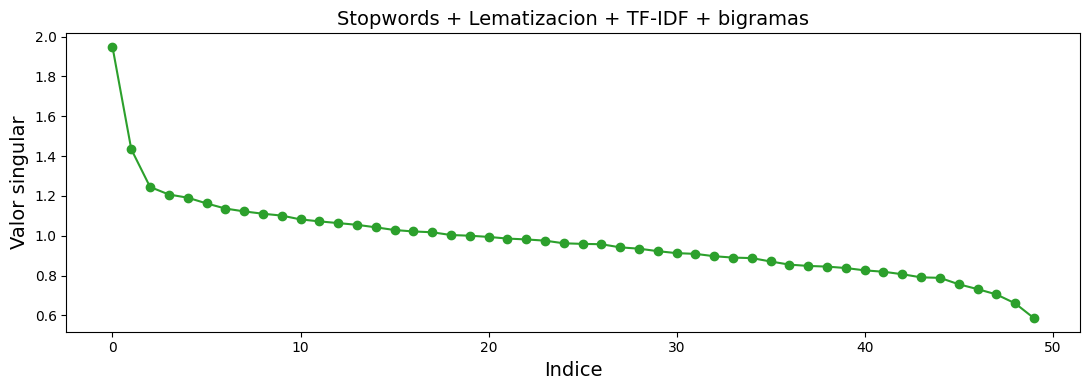

In [56]:
plt.figure(figsize=(11, 4))

plt.plot(S, marker="o", color="tab:green")
plt.title("Stopwords + Lematizacion + TF-IDF + bigramas", fontsize=14)
plt.xlabel("Indice", fontsize=14)
plt.ylabel("Valor singular", fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(carpeta_figuras, 'valores_singulares.png'), dpi=300, bbox_inches='tight')
plt.show()

##### El gráfico presenta una caída entre k=1 y k=3. En general, podemos decir que la estructura del problema se concentra en las primeras 3, por lo que este contexto, nos conviene elegir el k asociado a esta caída, así el modelo puede capturar lo más importante. Por esto consideraremos k = 3 por el 'criterio del codo'.

## P7. (Representacion de documentos y terminos en baja dimension)

In [57]:
comp_x = 0
comp_y = 1

# valores singulares correspondientes
sigma_a = S[comp_x]
sigma_b = S[comp_y]

# Construimos las matrices de coordenadas 2D para el gráfico
D2 = np.array([sigma_a * Vt[comp_x, :], 
               sigma_b * Vt[comp_y, :]])

# Coordenadas de Términos (T2)
T2 = np.array([U[:, comp_x] * sigma_a, 
               U[:, comp_y] * sigma_b]).T

print(f"Forma de D2 (2 x n_canciones): {D2.shape}")
print(f"Forma de T2 (n_terminos x 2): {T2.shape}")

Forma de D2 (2 x n_canciones): (2, 50)
Forma de T2 (n_terminos x 2): (865, 2)


## Visualización de documentos

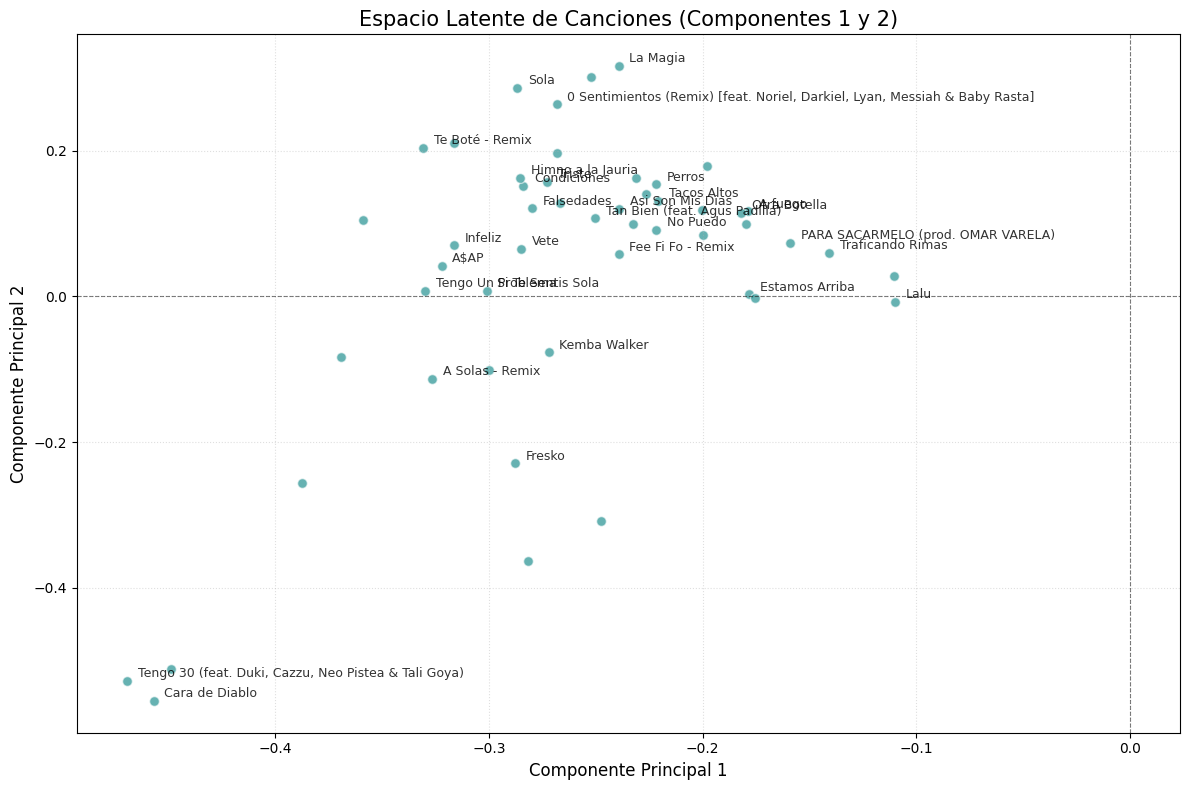

In [58]:
plt.figure(figsize=(12, 8))

plt.scatter(D2[comp_x, :], D2[comp_y, :], alpha=0.6, c='teal', edgecolors='white', s=50)

for i, title in enumerate(df['track_name']):  # Solo las primeras 50 canciones
    # Solo ponemos texto si la canción está algo alejada del centro 
    if i < 30: 
        plt.text(D2[comp_x, i] + 0.005, D2[comp_y, i] + 0.005, title, fontsize=9, alpha=0.8)

# Líneas de referencia para el origen
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.title(f"Espacio Latente de Canciones (Componentes {comp_x+1} y {comp_y+1})", fontsize=15)
plt.xlabel(f"Componente Principal {comp_x+1}", fontsize=12)
plt.ylabel(f"Componente Principal {comp_y+1}", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(carpeta_figuras, 'espacio_latente_canciones.png'), dpi=300, bbox_inches='tight')
plt.show()

## Visualización de términos

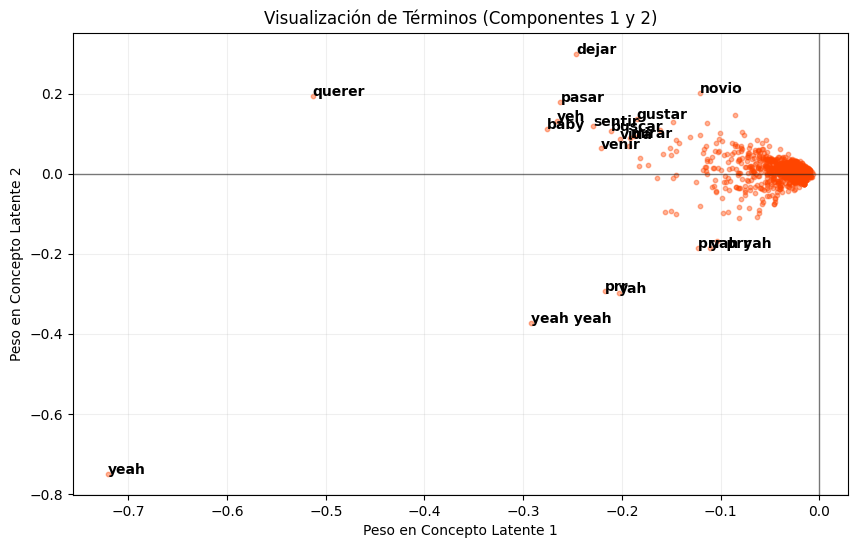

In [59]:
plt.figure(figsize=(10, 6))
# T2 tiene forma (m, 2), así que T2[:, 0] es X y T2[:, 1] es Y
plt.scatter(T2[:, comp_x], T2[:, comp_y], alpha=0.4, c='orangered', s=10)

# Buscamos las palabras con más peso
dist_t = np.sqrt(T2[:, comp_x]**2 + T2[:, comp_y]**2)
umbral_t = np.percentile(dist_t, 98) # Solo el top 2% de palabras

for i, word in enumerate(vocabulario_final):
    if dist_t[i] > umbral_t:
        plt.text(T2[i, comp_x], T2[i, comp_y], word, fontsize=10, fontweight='bold')

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)
plt.title(f"Visualización de Términos (Componentes {comp_x+1} y {comp_y+1})")
plt.xlabel(f"Peso en Concepto Latente {comp_x+1}")
plt.ylabel(f"Peso en Concepto Latente {comp_y+1}")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(carpeta_figuras, 'visualizacion_terminos.png'), dpi=300, bbox_inches='tight')
plt.show()

##### Para las visualizaciones se consideraron las componentes 1 y 2. En los graficos, la separación más notable se evidencia marcada por la componente 2, en dónde tanto la temática de las canciones como relación semántica entre palabra se diferencia entre el grupo sobre la componente y bajo ella. Podemos decir que arriba hay mayor densidad léxica, mientras que abajo la letra de las canciones es menos seria (términos con bajo valor connotativo o léxico). En cuanto a términos, estos se encuentran concentrados cerca del origen cargados hacia la izquierda, mientras que para la visualización de documentos, ocurre lo mismo, pero se dispersan más a lo largo del eje horizontal.

## P8. Exploración semántica

In [60]:
# IDENTIFICAR TEMAS IMPORTANTES usando vector U (términos, canciones)
for i in range(2):
    # Usamos el vector del componente 
    componente = U[:, i]
    
    # Obtenemos índices palabras de mayo peso, usando las 10 palabras mas importantes
    indices_superior = np.argsort(componente)[-10:][::-1]
    
    # Obtenemos los índices de las palabras con menor peso, 10 palabras menos importantes
    indices_inferior = np.argsort(componente)[:10]
    palabras_importantes  = list(vocabulario_final[indices_superior]) +  list(vocabulario_final[indices_inferior])
    
    print(f"------------------- TEMA / COMPONENTE {i+1} ----------------------------")
    print(f"Palabras representativas: {vocabulario_final[indices_superior]}")
    print(f"Palabras opuestas : {vocabulario_final[indices_inferior]}")


------------------- TEMA / COMPONENTE 1 ----------------------------
Palabras representativas: ['babys' 'oye' 'salir caro' 'retirar' 'malo suerte' 'peso' 'rojo' 'caleta'
 'oler rico' 'natural']
Palabras opuestas : ['yeah' 'querer' 'yeah yeah' 'baby' 'yeh' 'pasar' 'dejar' 'sentir' 'venir'
 'prr']
------------------- TEMA / COMPONENTE 2 ----------------------------
Palabras representativas: ['dejar' 'novio' 'querer' 'pasar' 'novio dejar' 'gustar' 'yeh' 'perro'
 'olvir' 'sentir']
Palabras opuestas : ['yeah' 'yeah yeah' 'yah' 'prr' 'prr prr' 'yah yah' 'gang' 'wuh wuh'
 'pinky' 'calle']


In [61]:
# Lo mismo con las canciones mas importantes pero usando el vector Vt (concepto, canciones)

for i in range(2):
    # Usamos el vector del componente 
    componente = Vt[i,:]
    
    # Obtenemos índices palabras de mayo peso, usando las 10 palabras mas importantes
    indices_superior = np.argsort(componente)[-10:][::-1]
    
    # Obtenemos los índices de las palabras con menor peso, 10 palabras menos importantes
    indices_inferior = np.argsort(componente)[:10]
    canciones_limpia = np.array([str(n).strip() for n in df['track_name'].values])

    canciones_importantes  = list(canciones_limpia[indices_superior]) +  list(canciones_limpia[indices_inferior])
    
    print(f"------------------- TEMA / COMPONENTE {i+1} ----------------------------")
    print(f"canciones representativas: {canciones_limpia[indices_superior]}")
    print(f"canciones opuestas: {canciones_limpia[indices_inferior]}")

------------------- TEMA / COMPONENTE 1 ----------------------------
canciones representativas: ['Lalu' 'Caro' 'Traficando Rimas' 'PARA SACARMELO (prod. OMAR VARELA)'
 'Brindemos' 'Estamos Arriba' 'A fuego' 'Grita' 'Otra Botella'
 'Anda Y Ve Lo Dudo']
canciones opuestas: ['Tengo 30 (feat. Duki, Cazzu, Neo Pistea & Tali Goya)' 'Cara de Diablo'
 'No Le Baje (Como en los Viejos Tiempos)' 'No Creo'
 'NEGOCIANDO POR TIEMPO (prod. SHIGANT-G)' 'Good Vibes' 'Te Boté - Remix'
 'Tengo Un Problema' 'A Solas - Remix' 'A$AP']
------------------- TEMA / COMPONENTE 2 ----------------------------
canciones representativas: ['La Magia' 'Si Tu Novio Te Deja Sola' 'Sola'
 '0 Sentimientos (Remix) [feat. Noriel, Darkiel, Lyan, Messiah & Baby Rasta]'
 'NI BIEN NI MAL' 'Te Boté - Remix' 'MIA (feat. Drake)'
 'Anda Y Ve Lo Dudo' 'Himno a la Jauria' 'Ella busca']
canciones opuestas: ['Cara de Diablo' 'Tengo 30 (feat. Duki, Cazzu, Neo Pistea & Tali Goya)'
 'No Le Baje (Como en los Viejos Tiempos)' 'Pinky Ring - 

In [62]:
# Definimos los componentes principales  1 y 2
idx = [0, 1]

# Definimos los vectores y valores 
S_12 = S[idx]      # Valores singulares principales 1 y 2
U_12 = U[:, idx]   # Vectores de términos para las componentes 1 y 2
VT_12 = Vt[idx, :] # Vectores de documentos para las componentes 1 y 2

# Calculamos las matriz de coordenadas de documentos de espacio reducido
docs_12 = (S_12 * VT_12.T).T

# Calculamos las matriz de coordenadas de documentos de espacio reducido
terms_12 = U_12 * S_12

# Limpieza de canciones 
canciones_limpia = np.array([str(n).strip() for n in df['track_name'].values])

def buscar_similares(nombre, lista_nombres, matriz_reducida, n=5):
    # busca similares segun coincidencias
    if nombre not in lista_nombres:
        coincidencias = [c for c in lista_nombres if nombre.lower() in c.lower()]
        if not coincidencias:
            return f"'{nombre}' no se encuentra en las canciones"
        nombre = coincidencias[0]
    
    # Obtenemos el índice del elemento
    idx = np.where(lista_nombres == nombre)[0][0]
    
    # Normalizamos la matriz para que siempre sea (elementos, dimensiones)
    puntos = matriz_reducida.T if matriz_reducida.shape[0] == 2 else matriz_reducida
    
    # Extraemos el vector del elemento consultado
    vector_objetivo = puntos[idx]
    
    # Calculamos la distancia euclidiana entre el objetivo y todos los demás
    distancias = np.linalg.norm(puntos - vector_objetivo, axis=1)
    
    # Ordenamos y tomamos los n más cercanos, es decir los que poseean la distancia mas pequeña
    indices_cercanos = np.argsort(distancias)[1:n+1]
    
    return lista_nombres[indices_cercanos]

# -------------------- EJEMPLOS------------------------------------------
print("----------- EJEMPLO 1: Relaciones entre términos (palabras importantes) ----------------")

# Comparacion entre términos
for palabra in palabras_importantes:
    similares = buscar_similares(palabra, vocabulario_final, terms_12)
    print(f"Palabras más cercanas a '{palabra}': {similares}")

----------- EJEMPLO 1: Relaciones entre términos (palabras importantes) ----------------
Palabras más cercanas a 'dejar': ['pasar' 'novio' 'yeh' 'gustar' 'sentir']
Palabras más cercanas a 'novio': ['novio dejar' 'olvir' 'perro' 'gustar' 'anda']
Palabras más cercanas a 'querer': ['pasar' 'baby' 'yeh' 'dejar' 'sentir']
Palabras más cercanas a 'pasar': ['yeh' 'sentir' 'baby' 'gustar' 'buscar']
Palabras más cercanas a 'novio dejar': ['olvir' 'hora' 'anda' 'valorar' 'dile']
Palabras más cercanas a 'gustar': ['amor' 'perro' 'buscar' 'pensar' 'sentir']
Palabras más cercanas a 'yeh': ['baby' 'sentir' 'pasar' 'buscar' 'vida']
Palabras más cercanas a 'perro': ['amor' 'olvir' 'gustar' 'banda' 'dile']
Palabras más cercanas a 'olvir': ['anda' 'dile' 'novio dejar' 'perro' 'banda']
Palabras más cercanas a 'sentir': ['buscar' 'yeh' 'vida' 'baby' 'gustar']
Palabras más cercanas a 'yeah': ['yeah yeah' 'prr' 'yah' 'prr prr' 'yah yah']
Palabras más cercanas a 'yeah yeah': ['prr' 'yah' 'prr prr' 'yah yah' 

### Podemos ver que las entre las palabras mas relevantes se encuentra: 'querer', 'dejar', 'novio', 'gustar', 'sentir', lo que nos da cuenta de conceptos de amor/desamor que coincide con lo estipulado en la hipótesis.

In [63]:
print("\n--------- EJEMPLO 2: Relaciones entre canciones -----------")

# Comparar  entre canciones
for cancion in canciones_importantes:
    similares_docs = buscar_similares(cancion, canciones_limpia, docs_12)
    print(f"Canciones más cercanas a '{cancion}': {similares_docs}")



--------- EJEMPLO 2: Relaciones entre canciones -----------
Canciones más cercanas a 'La Magia': ['Si Tu Novio Te Deja Sola' 'Sola'
 '0 Sentimientos (Remix) [feat. Noriel, Darkiel, Lyan, Messiah & Baby Rasta]'
 'MIA (feat. Drake)' 'NI BIEN NI MAL']
Canciones más cercanas a 'Si Tu Novio Te Deja Sola': ['La Magia' 'Sola'
 '0 Sentimientos (Remix) [feat. Noriel, Darkiel, Lyan, Messiah & Baby Rasta]'
 'MIA (feat. Drake)' 'NI BIEN NI MAL']
Canciones más cercanas a 'Sola': ['0 Sentimientos (Remix) [feat. Noriel, Darkiel, Lyan, Messiah & Baby Rasta]'
 'Si Tu Novio Te Deja Sola' 'La Magia' 'NI BIEN NI MAL'
 'MIA (feat. Drake)']
Canciones más cercanas a '0 Sentimientos (Remix) [feat. Noriel, Darkiel, Lyan, Messiah & Baby Rasta]': ['Sola' 'Si Tu Novio Te Deja Sola' 'La Magia' 'MIA (feat. Drake)'
 'NI BIEN NI MAL']
Canciones más cercanas a 'NI BIEN NI MAL': ['Te Boté - Remix' 'MIA (feat. Drake)' 'Himno a la Jauria' 'Condiciones'
 'Triste']
Canciones más cercanas a 'Te Boté - Remix': ['NI BIEN NI 

### Para las canciones mas importantes nos encontramos con 'Sola', '0 sentimientos', 'La Magia', 'Te Boté', que tambien habla de canciones sobre amor/desamor mas que de éxito.

In [64]:
print("\n------------EJEMPLO 3: Interpretación de valores de componentes------------------------------------------")
# Analizamos qué palabras pesan más en la Componente 2

pesos = U[:, 1]
extremo_superior = vocabulario_final[np.argsort(pesos)[-10:]]
extremo_inferior = vocabulario_final[np.argsort(pesos)[:10]]

print(f"Palabras en el extremo superior de Componente 2: {extremo_superior}")
print(f"Palabras en el extremo inferior de Componente 2: {extremo_inferior}")


------------EJEMPLO 3: Interpretación de valores de componentes------------------------------------------
Palabras en el extremo superior de Componente 2: ['sentir' 'olvir' 'perro' 'yeh' 'gustar' 'novio dejar' 'pasar' 'querer'
 'novio' 'dejar']
Palabras en el extremo inferior de Componente 2: ['yeah' 'yeah yeah' 'yah' 'prr' 'prr prr' 'yah yah' 'gang' 'wuh wuh'
 'pinky' 'calle']


#### Vemos entonces que de la hipotesis se logró que los temas que poseen mas pesos fuesen relacionados con amor/desamor, pero no tanto con éxito y encontramos que la Onomatopeyas se utilizan bastante, ya que tienen bastante peso  en el vocabulario usado

## P9. Discusión, limitaciones y conclusiones

##### La hipótesis se cumple parcialmente